# This is to deal only with the ID = 5 File for finding NSC

In [3]:
import numpy as np
import pandas, os, astropy, scipy, math
import matplotlib.pyplot as plt
import sklearn
from photutils.aperture import CircularAperture, SkyCircularAperture, aperture_photometry, EllipticalAperture, SkyEllipticalAperture
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.wcs.utils import pixel_to_skycoord
import astropy.io.fits as fits
from reproject import reproject_interp
import img_scale
from mpl_toolkits.axes_grid1 import Divider, Size
from astropy.cosmology import FlatLambdaCDM 
from astropy.wcs.utils import proj_plane_pixel_scales

In [4]:
# Writing a function to calculate the magnitude difference bewteen the 2 largest objects
def max_mag_diff(magar):
    lstmag = magar.tolist()
    sortedlstmag = sorted(lstmag)
    magdif1 = sortedlstmag[0] - sortedlstmag[1]
    print(" The magnitude difference between the brightest and 2nd brightest object is {}".format(magdif1))

In [5]:
galcen = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/55_SMDG1411053-051319_gal_loc.csv')
galcenx55 = galcen['xc'].values[0]
galceny55 = galcen['yc'].values[0]
cut_cat55 = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/55_SMDG1411053-051319_cut_catalog.csv')
cut_cat55.columns

Index(['Unnamed: 0', 'ext', 'chip', 'xc', 'yc', 'chi', 'snr', 'sharpness',
       'roundness', 'pa', 'crowding', 'objtype', 'F606W_count', 'F606W_sky',
       'F606W_count_rate', 'F606W_count_rate_uncer', 'F606W_mag_vega',
       'F606W_mag_ubvri', 'F606W_mag_uncer', 'F606W_chi', 'F606W_snr',
       'F606W_sharpness', 'F606W_roundness', 'F606W_crowding', 'F606W_flag',
       'F814W_count', 'F814W_sky', 'F814W_count_rate',
       'F814W_count_rate_uncer', 'F814W_mag_vega', 'F814W_mag_ubvri',
       'F814W_mag_uncer', 'F814W_chi', 'F814W_snr', 'F814W_sharpness',
       'F814W_roundness', 'F814W_crowding', 'F814W_flag', 'aper_4', 'aper_8',
       'newconcent'],
      dtype='object')

In [6]:
# Define cuts that we are using(comment out this cell to get the original data)
use_cat = cut_cat55

max_mag = 35.  # Maxmum mag (Telescope cut)
snr_thresh = 3.  # For nearby, 5
# crowd_thresh = 0.5 #[mag], Normal cut  
# sharp_thresh = 0.25 #Normal cut  defraction spikes
# round_thresh = 3.  #Weak constraint (elongated)
flag_thresh = np.array([0, 2])
flag_label = np.array(['Good', 'Edge', 'Bad,Sat-pixel', 'Edge+badpixel'])

## Instrumental VEGAMAG magnitude cut
print(f"Total dolphot catalogue length: {len(use_cat)}")
print(f"Require: mag < {max_mag}")
condition = (use_cat.iloc[:,16] < max_mag) & (use_cat.iloc[:,29] < max_mag)
sub_dolcut_cat = use_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## SNR cut
print(f"Require: S/N > {snr_thresh}.")
condition = (sub_dolcut_cat.iloc[:,20] > snr_thresh) & (sub_dolcut_cat.iloc[:,33] > snr_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Object Type cut
print("Remove sources that are not type point-like.")
condition = (sub_dolcut_cat.iloc[:,11] <= 2)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Photometry quality flag cut
print("Remove sources that have flag= ", flag_thresh, "or", flag_label[flag_thresh])
condition = np.isin(sub_dolcut_cat.iloc[:,24], flag_thresh) & np.isin(sub_dolcut_cat.iloc[:,37], flag_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

cut_cat55 = sub_dolcut_cat 

Total dolphot catalogue length: 94686
Require: mag < 35.0
New catalogue length: 94505
Require: S/N > 3.0.
New catalogue length: 8629
Remove sources that are not type point-like.
New catalogue length: 7097
Remove sources that have flag=  [0 2] or ['Good' 'Bad,Sat-pixel']
New catalogue length: 7065


In [8]:
#creating 2 numpy arrays that hold the xc and yc of each bright object
xcgal55 = cut_cat55['xc'].to_numpy()
ycgal55 = cut_cat55['yc'].to_numpy()
f606mag55 = cut_cat55['F606W_mag_vega'].to_numpy()
f814mag55 = cut_cat55['F814W_mag_vega'].to_numpy()

In [9]:
#calculating the distance from the centre of the galaxy for each bright object
distgal55 = np.sqrt((xcgal55 - galcenx55)**2 + (ycgal55 - galceny55)**2)


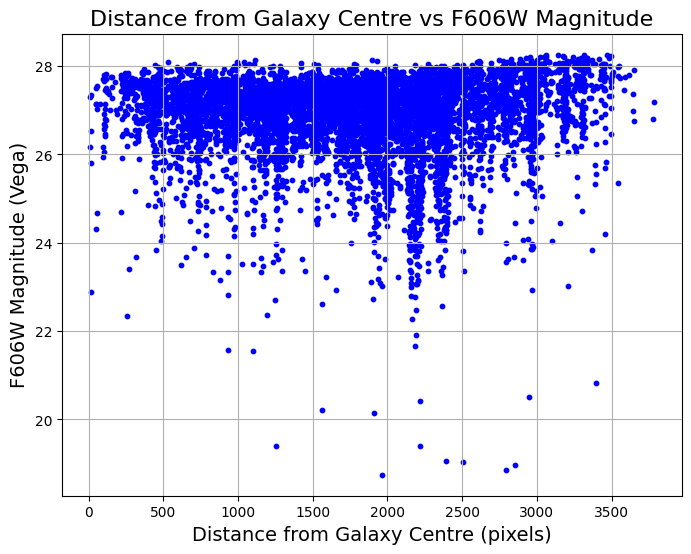

In [10]:
#plotting distance vs magnitude for F606W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

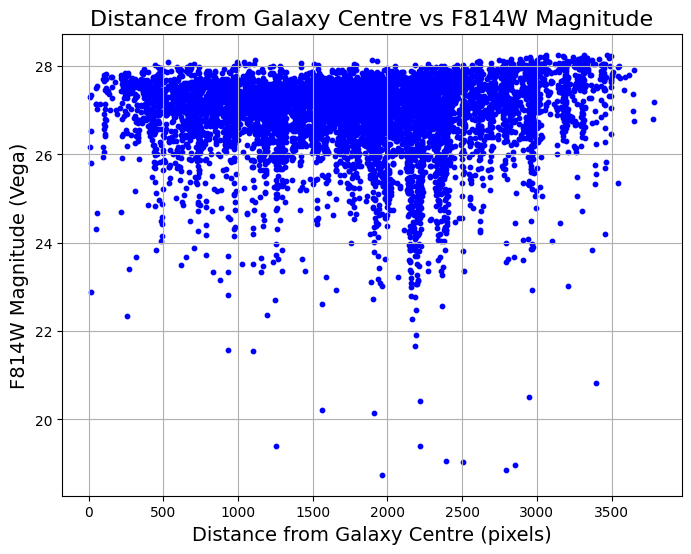

In [11]:
#plotting the distance vs magnitude for F814W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

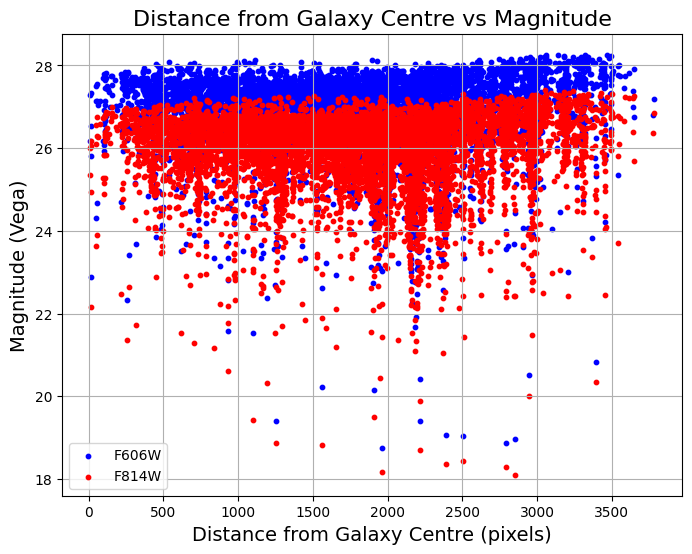

In [12]:
#plotting distance vs magnitude for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10, label='F606W')
plt.scatter(distgal55, f814mag55, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [13]:
# converting pixel in re(arcsec) to pixels
re_arcsec55 = 18.84

hdul55 = fits.open('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/ID_55_F606/MAST_2025-11-11T04_33_41.543Z/HST/jece78010_drc.fits')
if len(hdul55) > 1:
    hdr55 = hdul55[1].header
else:
    hdr55 = hdul55[0].header
wcs55 = WCS(hdr55)
pixel_scale_degrees55 = proj_plane_pixel_scales(wcs55)
scale_arcsec_per_pixel55 = pixel_scale_degrees55[0] * 3600
scale_pixel_per_arcsec55 = 1 / scale_arcsec_per_pixel55
re_pixels55 = re_arcsec55 * scale_pixel_per_arcsec55
print(re_pixels55)

376.8000000000028


In [14]:
#refining the bright object list to only include objects within re and finding the colour of the objects
distgal_re55 = distgal55[distgal55 <= re_pixels55]
f606mag_re55 = f606mag55[distgal55 <= re_pixels55]
f814mag_re55 = f814mag55[distgal55 <= re_pixels55]
color55 = f606mag_re55 - f814mag_re55 

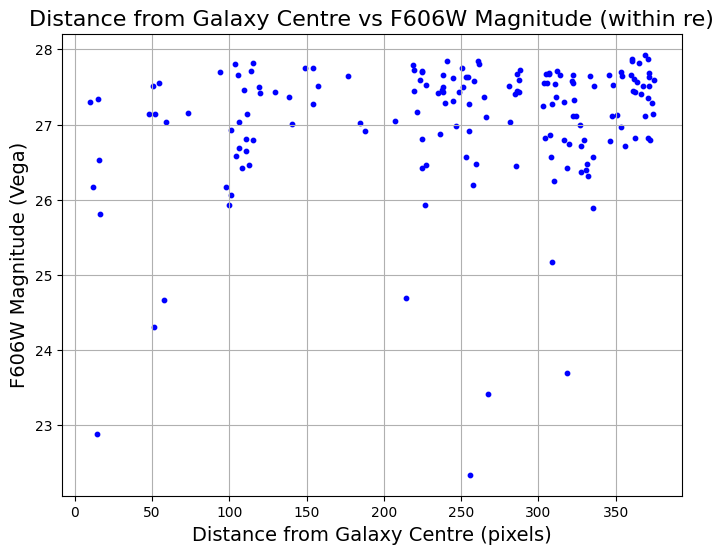

In [15]:
#plotting distance vs magnitude for f606w in re 
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f606mag_re55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()  

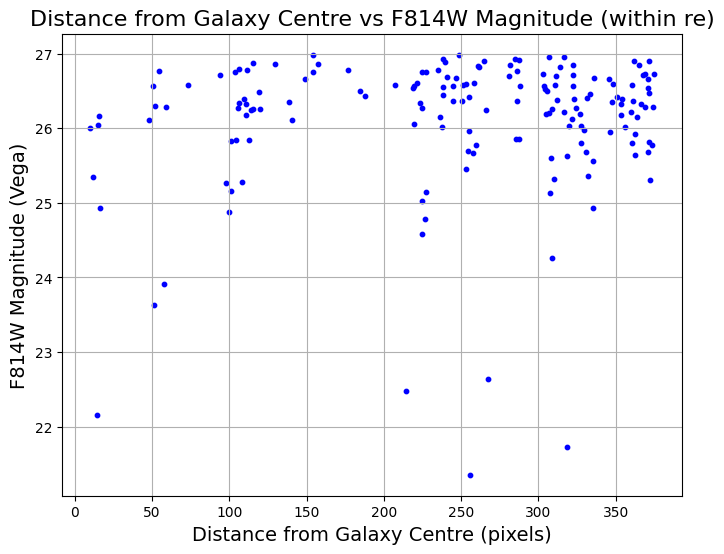

In [16]:
#plotting distance vs magnitude for f814w in re
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f814mag_re55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

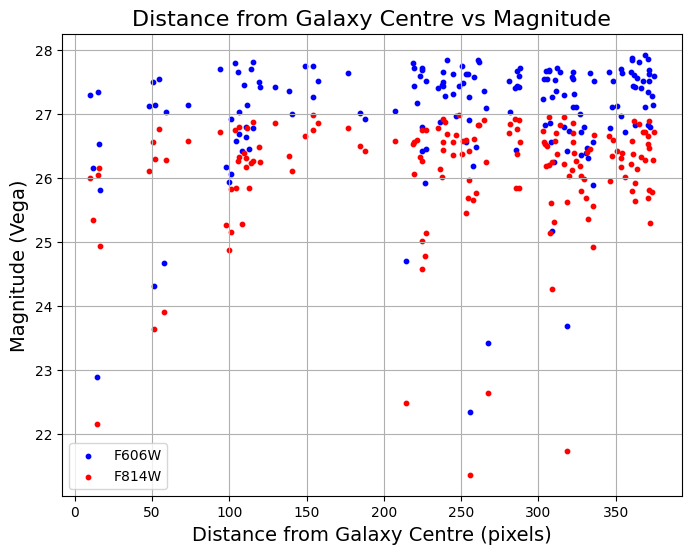

In [17]:
#plotting distance vs magnitude for the objects within re for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f606mag_re55, color='blue', s=10, label='F606W')
plt.scatter(distgal_re55, f814mag_re55, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [18]:
# normalising the distance in terms of re
distgal_re55_n = distgal_re55/re_pixels55

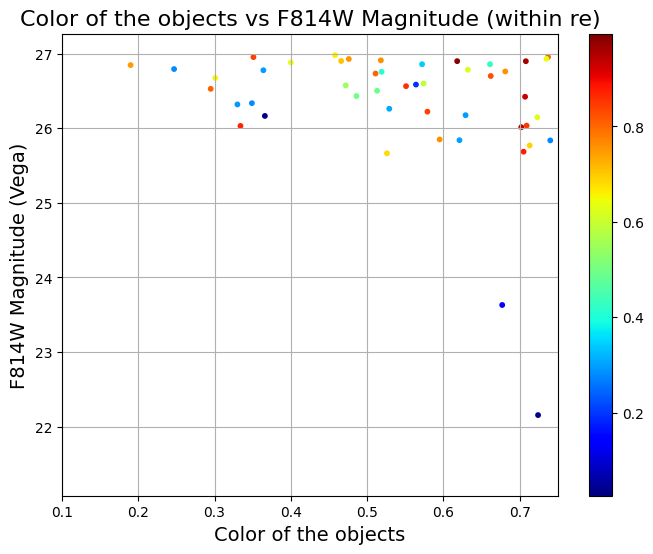

In [19]:
#plotting a color vs magnitude for the objects within a re
plt.figure(figsize=(8,6))

plt.scatter(color55, f814mag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.show()

In [21]:
#Converting into absolute Mag
distgalpc55 = 34.7 * 1e6
absmag_re55 = f814mag_re55 - 5*np.log10(distgalpc55/10)

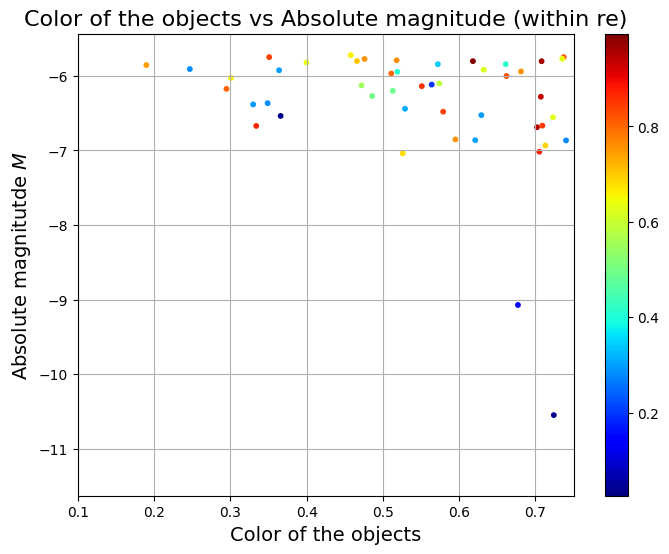

In [22]:
#plotting a color vs absolute magnitude for the objects within a re
plt.figure(figsize=(8,6))
plt.scatter(color55, absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs Absolute magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('Absolute magnitutde $M$', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.show()

In [23]:
#finding the mag of the object in 0.2 re
repixelsp255 = re_pixels55 * 0.2
print(repixelsp255)
f814mag_rep255 = f814mag55[distgal55 <= repixelsp255]

75.36000000000057


In [24]:
#Finding the mag difference of objects in 1 re then 0.2 re
max_mag_diff(f814mag_re55)# 1 re
max_mag_diff(f814mag_rep255)# 0.2 re

 The magnitude difference between the brightest and 2nd brightest object is -0.3710000000000022
 The magnitude difference between the brightest and 2nd brightest object is -1.4750000000000014


In [25]:
# adding concentration index to the catalog
newconcent55 = cut_cat55['newconcent']

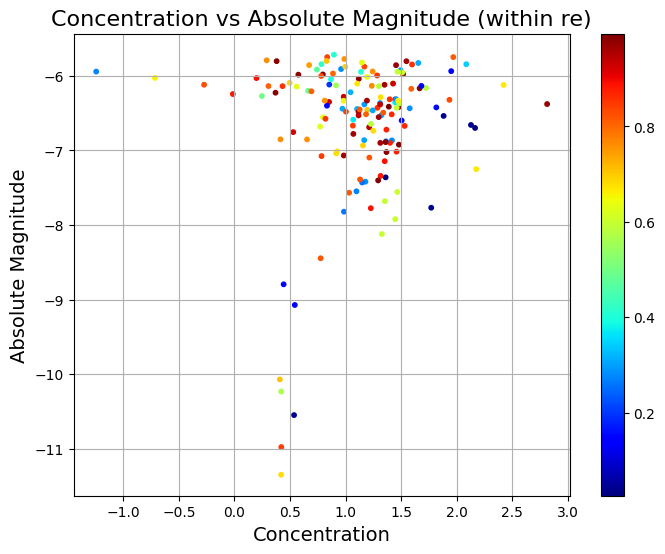

In [26]:
#Plotting the concentration vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent55[distgal55 <= re_pixels55], absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.grid()
plt.colorbar()
plt.show()

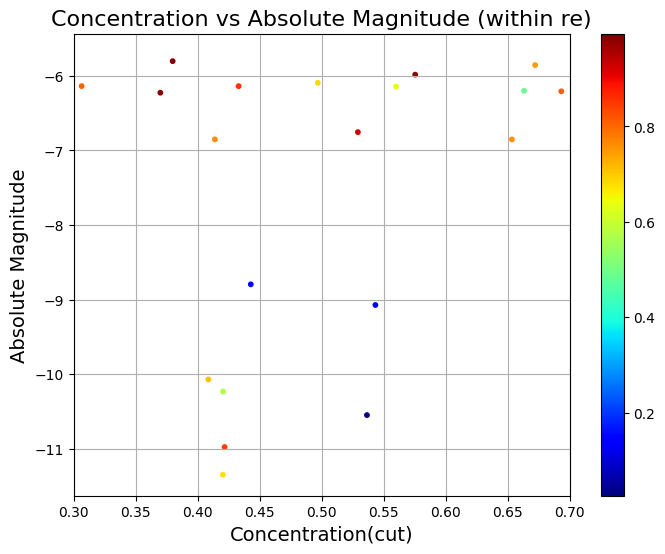

In [39]:
#Plotting the concentration(cut) vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent55[distgal55 <= re_pixels55], absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration(cut)', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.xlim(0.3, 0.7)
plt.grid()
plt.colorbar()
plt.show()

In [27]:
# accessing the fits file to get the header and the wcs information
F814W55 = hdul55[1].data
F814W55header = hdul55[1].header



In [43]:
# Writing code to find the index of the brightest object in 1 re 
minmag55 = 50
for i in range(len(f814mag_re55)):
    if f814mag_re55[i] < minmag55 and 0.1 < color55[i] < 0.75 and distgal_re55_n[i] < 0.2:
        minmag55 = f814mag_re55[i]
        objdist55 = distgal_re55[i]

index55 = 0
for i in range(len(f814mag55)):
    if f814mag55[i] == minmag55:
        index55 = i

print(index55)
print(minmag55)
print(f814mag_re55)
print(distgal_re55)
print(color55)

objxc55 = xcgal55[index55]
objyc55 = ycgal55[index55]
print(index55, minmag55)

40
22.156
[21.357 22.156 21.728 22.634 22.472 23.631 23.908 24.257 24.781 24.581
 24.881 25.022 24.934 24.928 25.154 25.283 25.272 25.145 25.341 25.135
 25.36  25.313 26.401 25.663 25.3   26.03  25.626 25.451 25.685 25.606
 25.558 25.839 25.768 25.849 25.68  25.836 25.779 26.164 26.174 25.634
 25.947 26.013 26.288 25.965 26.909 25.803 25.803 25.824 25.689 25.98
 26.318 26.034 25.813 26.26  26.764 26.171 26.335 26.057 26.146 25.85
 26.257 26.103 26.185 26.221 25.923 26.783 26.278 26.281 26.952 26.244
 26.043 26.501 26.114 26.351 26.415 26.43  26.978 26.003 26.732 26.599
 26.927 26.673 26.221 26.301 26.421 26.323 26.148 26.022 26.126 26.534
 26.273 26.792 26.845 26.527 26.266 26.251 26.76  26.776 26.273 26.186
 26.385 26.563 26.573 26.457 26.494 26.318 26.345 26.333 26.238 26.208
 26.584 26.387 26.369 26.481 26.388 26.758 26.367 26.444 26.857 26.656
 26.698 26.538 26.559 26.898 26.581 26.824 26.566 26.369 26.755 26.567
 26.579 26.38  26.563 26.597 26.368 26.88  26.723 26.557 26.9   26.66

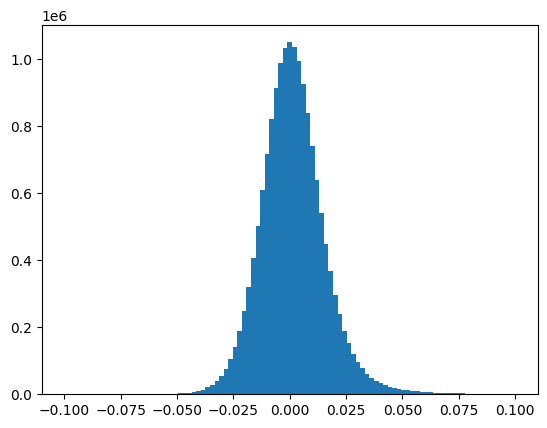

In [44]:
# Checking the distribution of pixel values in the F814W image
plt.hist(F814W55.ravel(),np.linspace(-0.1,0.1, 100))
plt.show()

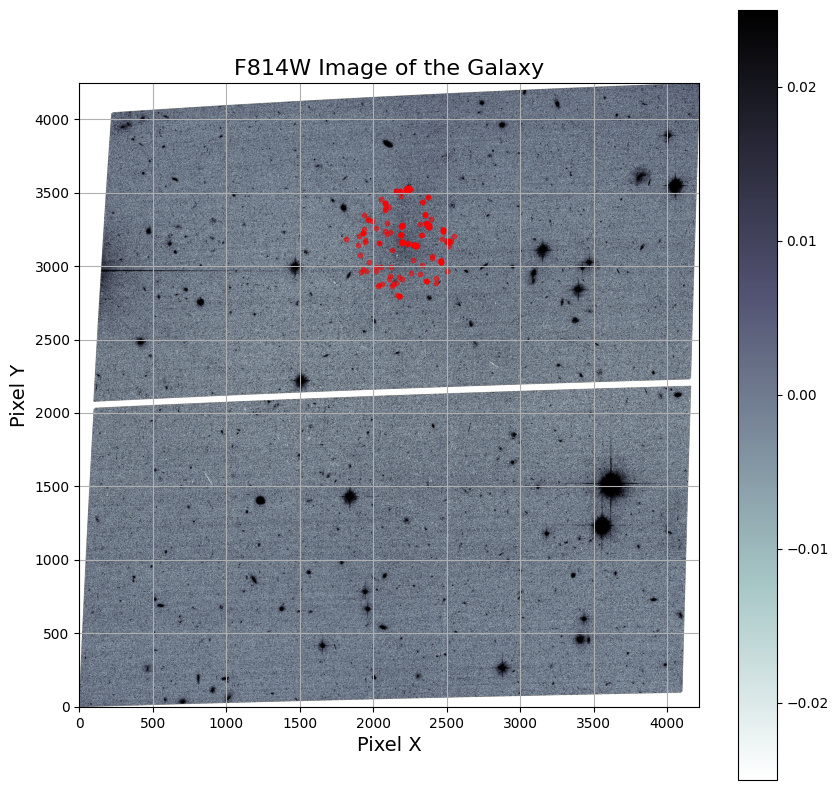

In [45]:
#Plotting the F814W image for the galaxy and overplot all the bright objects within re

fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=10, alpha = 0.5, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('Pixel X', fontsize=14)
plt.ylabel('Pixel Y', fontsize=14)
plt.grid()
plt.show()



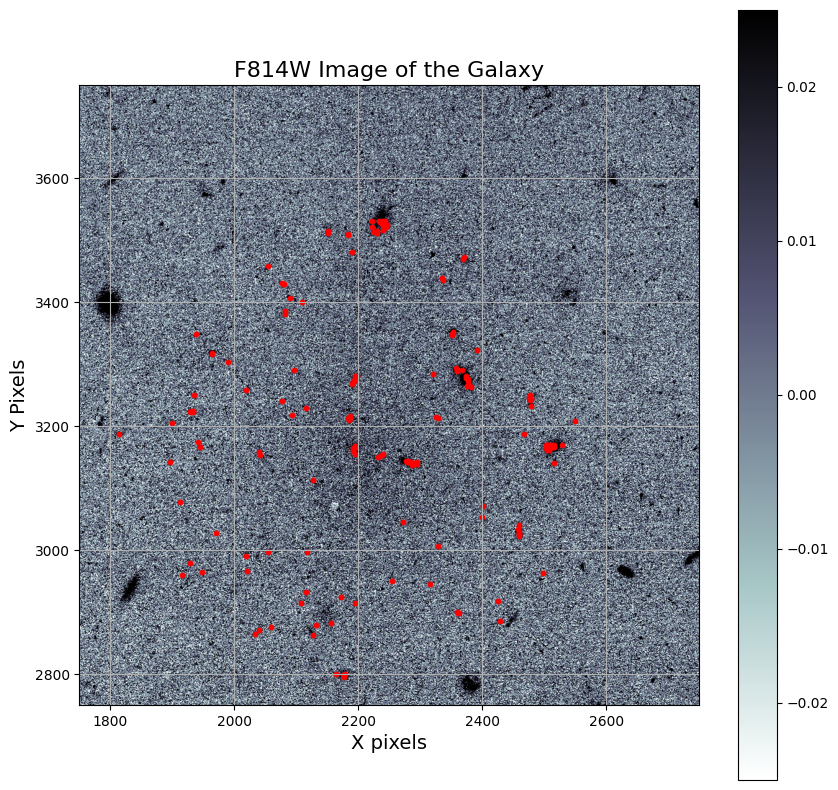

In [46]:
# zooming in for better visualization of the bright objects within re
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=10, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y Pixels', fontsize=14)
plt.xlim(1750, 2750)
plt.ylim(2750, 3750)
plt.grid()
plt.show()

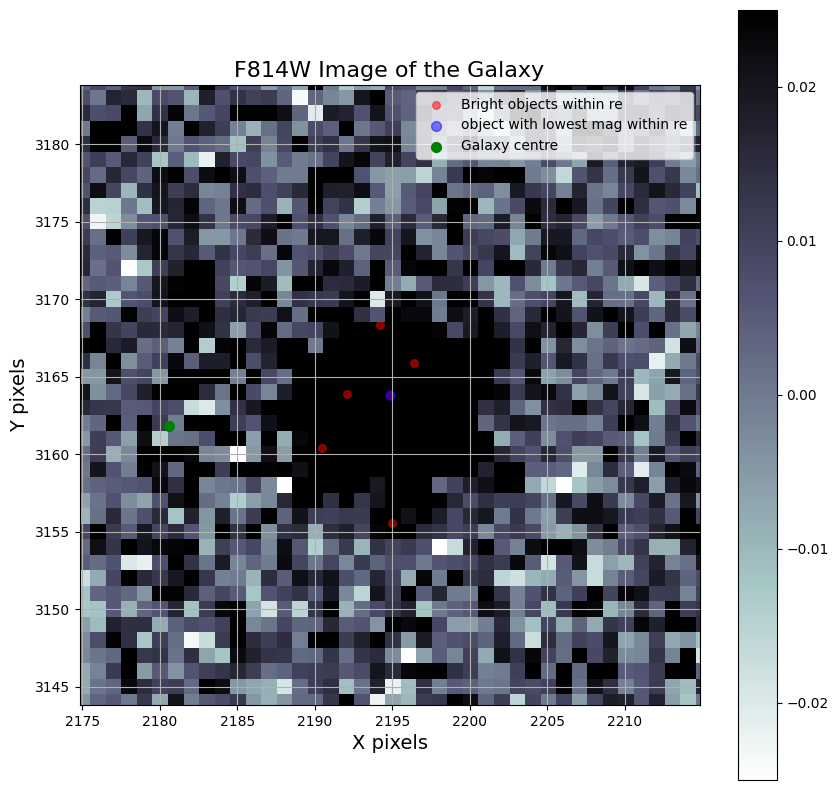

In [59]:
# zooming in even more to see the brightest and closest object to the centre of the galaxy
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, color='blue', s=50, alpha = 0.5, label='object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y pixels', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

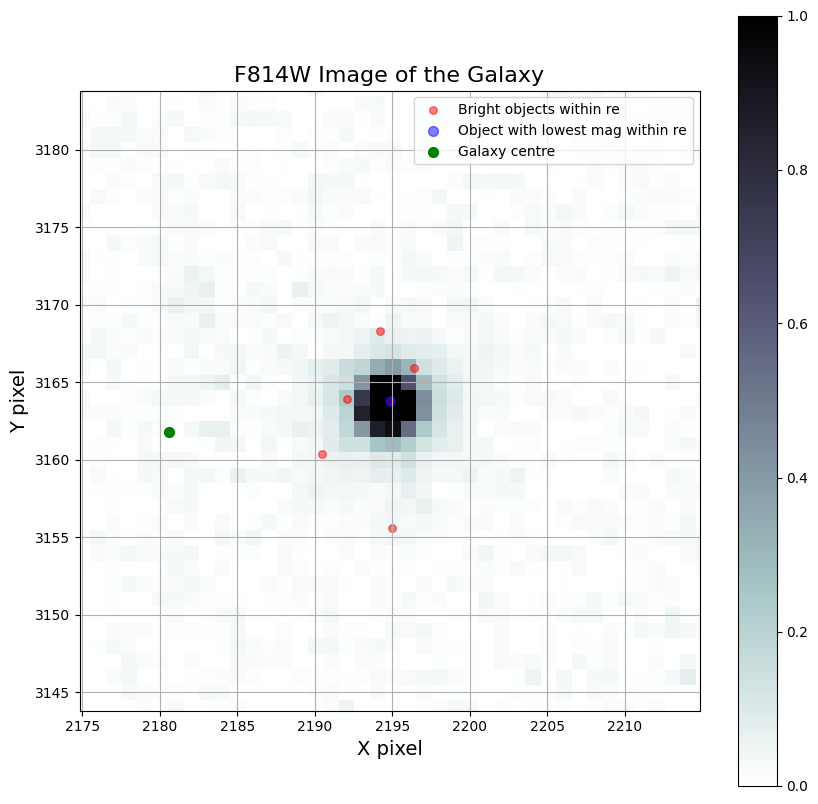

In [58]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = 0, vmax = 1)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, color='blue', s=50, alpha = 0.5, label='Object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

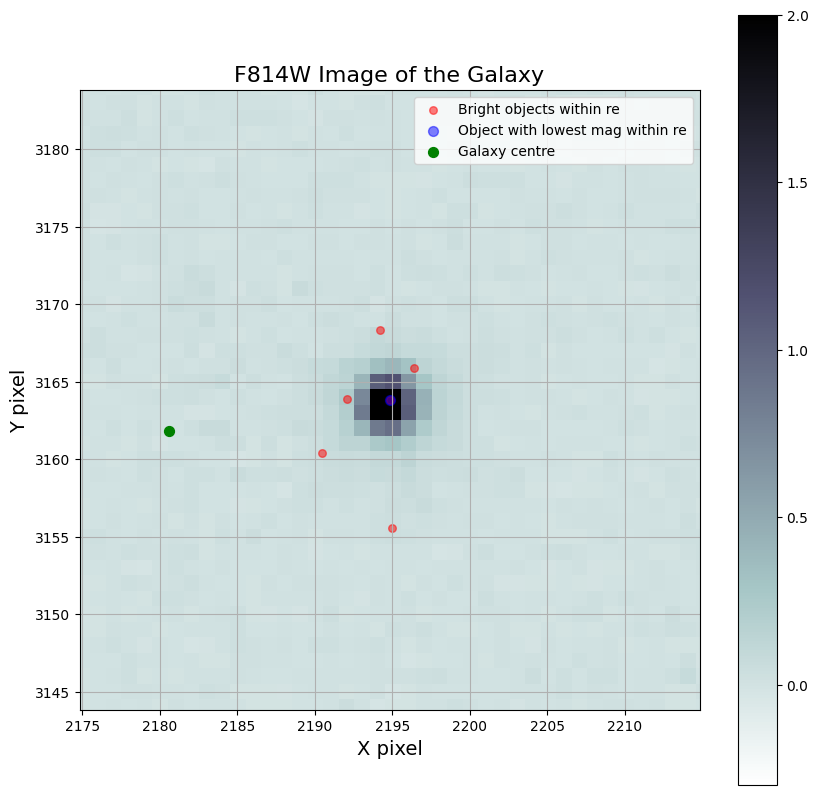

In [57]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, color='blue', s=50, alpha = 0.5, label='Object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

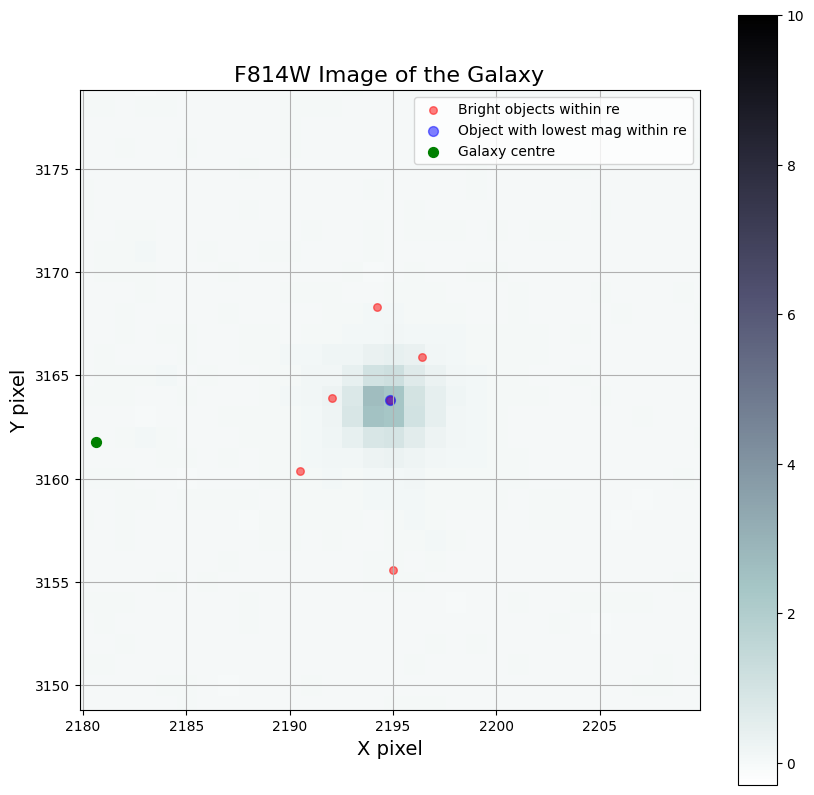

In [60]:
# Zooming in even more
lim = round(objdist55)+1
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 10)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, color='blue', s=50, alpha = 0.5, label='Object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-lim, objxc55+lim)
plt.ylim(objyc55-lim, objyc55+lim)
plt.legend()
plt.grid()
plt.show()

# Looks like there is an NSC here